# Session review

How the avatar behaved during one recorded session — `logs/NNN/`, straight from the
per-device CSVs. One session at a time, no comparison against anything.

Cartesian first, joints second: what the end-effector did is what the task is about,
and the joint traces are for explaining *how* it got there.

Two traces throughout:

- **setpoint** — `O_T_EE_cmd_world`, the motion generator's interpolated target after
  rate and acceleration limiting. Not the raw operator or policy command: that gets
  shaped before it reaches the controller, and only the shaped version is logged here.
- **measured** — `O_T_EE_world`.


In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation

LOGS = Path("../../logs")
ARMS = ("arm_left", "arm_right")
ENGAGED = 4
plt.rcParams["figure.figsize"] = (13, 7)

for d in sorted(LOGS.glob("[0-9][0-9][0-9]"))[-12:]:
    if (d / "arm_left.csv").exists():
        mb = sum(f.stat().st_size for f in d.glob("*.csv")) / 1e6
        print(f"{d.name}   {mb:7.1f} MB")

000      89.5 MB
001     107.2 MB
002      99.9 MB
003      64.6 MB
004      87.9 MB


In [22]:
SESSION = "004"
ARM     = "arm_left"    # the per-arm sections render one at a time
WINDOW  = "engaged"     # "engaged" (first..last ENGAGED sample) or "all"

## Load

In [23]:
def _pose(flat16):
    """Column-major flat 4x4 -> (pos [N,3], Rotation[N])."""
    m = np.asarray(flat16).reshape(-1, 4, 4).transpose(0, 2, 1)
    return m[:, :3, 3].copy(), Rotation.from_matrix(m[:, :3, :3])


def load_arm(folder, arm):
    df = pd.read_csv(folder / f"{arm}.csv", sep=";").dropna(subset=["state"])
    cols = lambda p, n: df[[f"{p}_{i}" for i in range(n)]].to_numpy()
    pos, rot = _pose(cols("O_T_EE_world", 16))
    spos, srot = _pose(cols("O_T_EE_cmd_world", 16))
    d = {"t_wall": df["wall_clock_ns"].to_numpy().astype(np.int64),
         "pos": pos, "rot": rot, "set_pos": spos, "set_rot": srot,
         "F_ext": cols("F_ext", 6),
         "q": cols("q", 7), "q_cmd": cols("q_cmd", 7), "dq": cols("dq", 7),
         "tau_J": cols("tau_J", 7), "tau_cmd": cols("tau_cmd", 7), "tau_ext": cols("tau_ext", 7),
         "gripper_width": df["gripper_width"].to_numpy(),
         "gripper_cmd": df["gripper_cmd"].to_numpy(),
         "grasp_state": df["grasp_state"].to_numpy(),
         "state": df["state"].to_numpy().astype(int)}
    if WINDOW == "engaged":
        idx = np.flatnonzero(d["state"] == ENGAGED)
        if len(idx) > 1:
            d = {k: v[idx[0]:idx[-1] + 1] for k, v in d.items()}
        else:
            print(f"{arm}: never ENGAGED -- showing the whole file instead")
    d["t"] = (d["t_wall"] - d["t_wall"][0]) * 1e-9
    return d


def load_head(folder):
    p = folder / "head.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p, sep=";").dropna(subset=["state"])
    d = {"q": df[["q_0", "q_1"]].to_numpy(), "q_cmd": df[["q_cmd_0", "q_cmd_1"]].to_numpy(),
         "state": df["state"].to_numpy().astype(int),
         "t_wall": df["wall_clock_ns"].to_numpy().astype(np.int64)}
    d["t"] = (d["t_wall"] - d["t_wall"][0]) * 1e-9
    return d


def deriv(t, x, smooth=25):
    """Finite difference plus a moving average; these are 500 Hz-ish signals."""
    d = np.gradient(x, t, axis=0)
    k = np.ones(smooth) / smooth
    return np.apply_along_axis(lambda c: np.convolve(c, k, mode="same"), 0, d)


def ang_vel(t, rot, smooth=25):
    """Angular velocity via rotvec of consecutive rotations -- stable near identity,
    unlike arccos of the trace, which at this rate is mostly float noise."""
    w = (rot[1:] * rot[:-1].inv()).as_rotvec() / np.diff(t)[:, None]
    w = np.vstack([w[:1], w])
    k = np.ones(smooth) / smooth
    return np.apply_along_axis(lambda c: np.convolve(c, k, mode="same"), 0, w)


def grid(axs, ncol=4):
    for ax in np.atleast_1d(axs).ravel():
        ax.grid(True, alpha=0.3)
    if np.atleast_1d(axs)[0].get_legend_handles_labels()[0]:
        np.atleast_1d(axs)[0].legend(ncol=ncol, fontsize=8)
    np.atleast_1d(axs)[-1].set_xlabel("t [s]")


folder = LOGS / SESSION
arms = {a: load_arm(folder, a) for a in ARMS}
head = load_head(folder)

print(f"\nsession {SESSION}  ({WINDOW} window)")
for name, d in arms.items():
    print(f"  {name}: {len(d['t']):7d} samples  {d['t'][-1]:6.1f} s  "
          f"{1 / np.median(np.diff(d['t'])):6.0f} Hz  "
          f"engaged {(d['state'] == ENGAGED).mean() * 100:5.1f}%  "
          f"|F| max {np.linalg.norm(d['F_ext'][:, :3], axis=1).max():5.1f} N")

def _smooth(x, k=101):
    """Centred moving average, same idea as the twist plots' `deriv`."""
    if k <= 1:
        return x
    w = np.ones(k) / k
    return np.apply_along_axis(lambda c: np.convolve(c, w, mode="same"), 0, x)


def xcorr(t, cmd, meas, max_lag_s=0.4, step=2):
    """Normalised cross-correlation vs lag, per axis. POSITIVE lag = the arm
    lags the setpoint; a peak left of zero would mean it leads, which a causal
    controller cannot do and would mean the comparison is wrong, not the robot.

    Correlation is recomputed on the overlapping segment at every lag rather
    than normalised once against the whole record. These traces have a strong
    low-frequency trend -- the arm works across the workspace -- so a single
    global normalisation lets overlap length dominate and the curve peaks at
    zero lag whatever the real offset is.
    """
    dt = float(np.median(np.diff(t)))
    n = int(round(max_lag_s / dt))
    shifts = np.arange(-n, n + 1, step)
    rs = np.empty((len(shifts), cmd.shape[1]))
    for j, L in enumerate(shifts):
        a, b = (cmd[:-L], meas[L:]) if L > 0 else (cmd[-L:], meas[:L]) if L < 0 else (cmd, meas)
        a = a - a.mean(0)
        b = b - b.mean(0)
        rs[j] = (a * b).sum(0) / np.sqrt((a * a).sum(0) * (b * b).sum(0))
    return shifts * dt * 1e3, rs


def lag_offset(t, cmd, meas, v_min=0.02, smooth=101, max_lag_s=0.4):
    v = _smooth(np.gradient(cmd, t, axis=0), smooth)
    e = _smooth(cmd - meas, smooth)
    lags, R = xcorr(t, cmd, meas, max_lag_s=max_lag_s)
    out = {k: np.full(cmd.shape[1], np.nan)
           for k in ("lag_ms", "slope_lag_ms", "offset_m", "r2")}
    for i in range(cmd.shape[1]):
        out["lag_ms"][i] = lags[np.argmax(R[:, i])]
        m = np.abs(v[:, i]) > v_min
        if m.sum() < 100:
            continue
        X = np.column_stack([v[m, i], np.ones(m.sum())])
        c, *_ = np.linalg.lstsq(X, e[m, i], rcond=None)
        out["slope_lag_ms"][i] = c[0] * 1e3
        out["offset_m"][i] = c[1]
        out["r2"][i] = 1 - (e[m, i] - X @ c).var() / e[m, i].var()
    out["_lags"], out["_R"] = lags, R
    return out



session 004  (engaged window)
  arm_left:   20546 samples    44.7 s     500 Hz  engaged 100.0%  |F| max  61.9 N
  arm_right:   20907 samples    44.7 s     500 Hz  engaged 100.0%  |F| max   2.1 N


## Cartesian

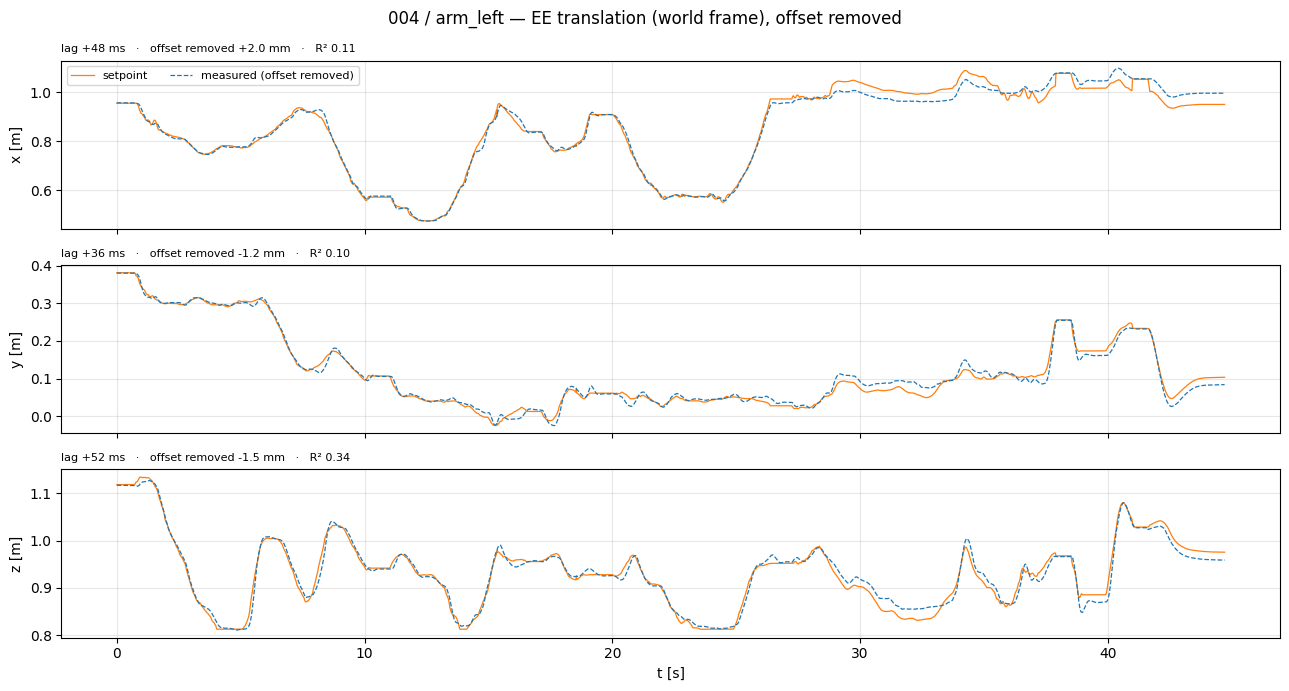

In [24]:
A = arms[ARM]
LAG = lag_offset(A["t"], A["set_pos"], A["pos"])

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(13, 7))
for i, lbl in enumerate("xyz"):
    axs[i].plot(A["t"], A["set_pos"][:, i], lw=0.9, color="tab:orange", label="setpoint")
    axs[i].plot(A["t"], A["pos"][:, i] + LAG["offset_m"][i], lw=0.9, ls="--",
                color="tab:blue", label="measured (offset removed)")
    axs[i].set_ylabel(f"{lbl} [m]")
    axs[i].set_title(f"lag {LAG['lag_ms'][i]:+.0f} ms   ·   offset removed "
                     f"{LAG['offset_m'][i] * 1e3:+.1f} mm   ·   R² {LAG['r2'][i]:.2f}",
                     fontsize=8, loc="left")
grid(axs, ncol=2)
plt.suptitle(f"{SESSION} / {ARM} — EE translation (world frame), offset removed")
plt.tight_layout()


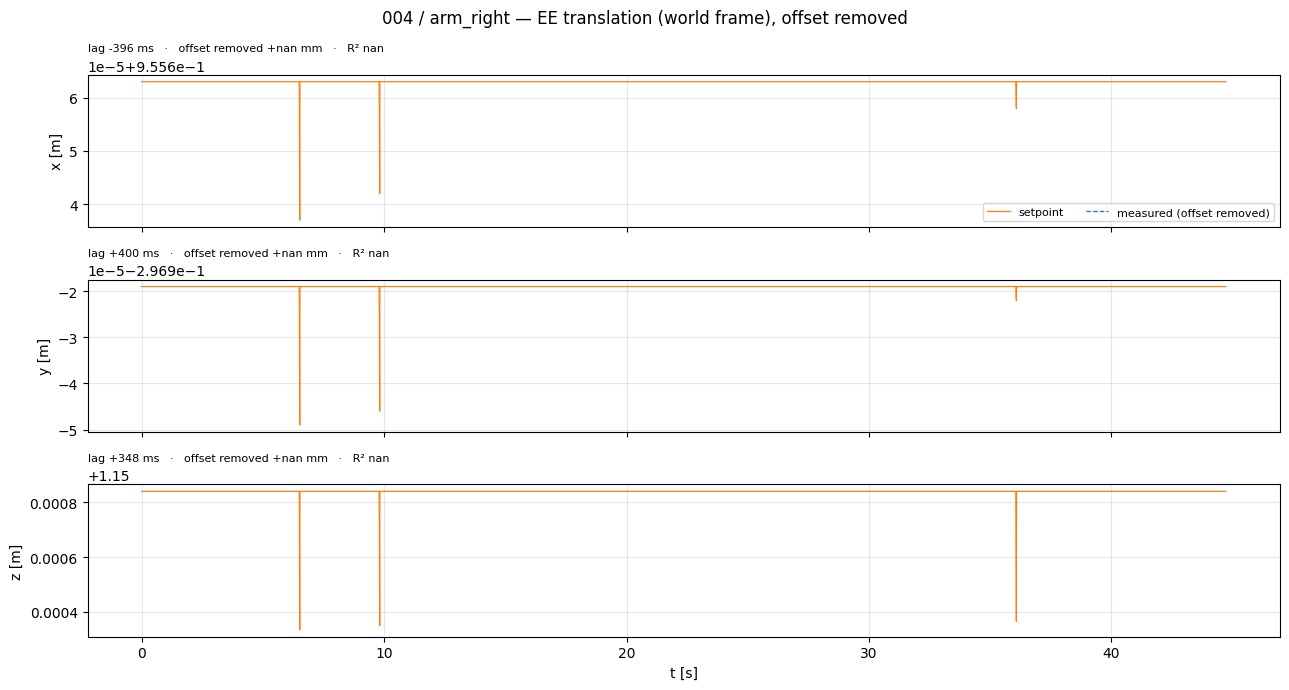

In [25]:
A = arms["arm_right"]
LAG = lag_offset(A["t"], A["set_pos"], A["pos"])

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(13, 7))
for i, lbl in enumerate("xyz"):
    axs[i].plot(A["t"], A["set_pos"][:, i], lw=0.9, color="tab:orange", label="setpoint")
    axs[i].plot(A["t"], A["pos"][:, i] + LAG["offset_m"][i], lw=0.9, ls="--",
                color="tab:blue", label="measured (offset removed)")
    axs[i].set_ylabel(f"{lbl} [m]")
    axs[i].set_title(f"lag {LAG['lag_ms'][i]:+.0f} ms   ·   offset removed "
                     f"{LAG['offset_m'][i] * 1e3:+.1f} mm   ·   R² {LAG['r2'][i]:.2f}",
                     fontsize=8, loc="left")
grid(axs, ncol=2)
plt.suptitle(f"{SESSION} / arm_right — EE translation (world frame), offset removed")
plt.tight_layout()

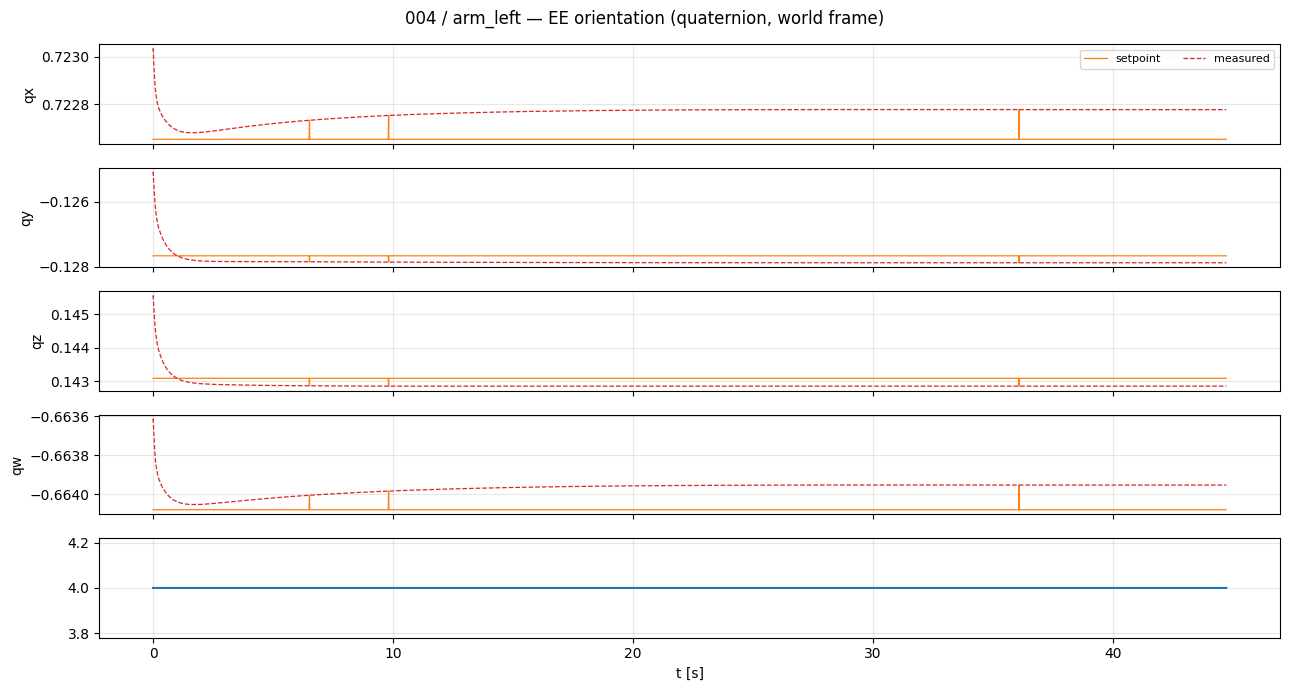

In [26]:
fig, axs = plt.subplots(5, 1, sharex=True, figsize=(13, 7))
qs, qm = A["set_rot"].as_quat(), A["rot"].as_quat()
for i, lbl in enumerate(["x", "y", "z", "w"]):
    axs[i].plot(A["t"], qs[:, i], lw=0.9, color="tab:orange", label="setpoint")
    axs[i].plot(A["t"], qm[:, i], lw=0.9, ls="--", color="tab:red", label="measured")
    axs[i].set_ylabel(f"q{lbl}")
axs[4].plot(A["t"], A["state"])
grid(axs)
plt.suptitle(f"{SESSION} / {ARM} — EE orientation (quaternion, world frame)")
plt.tight_layout()

20907


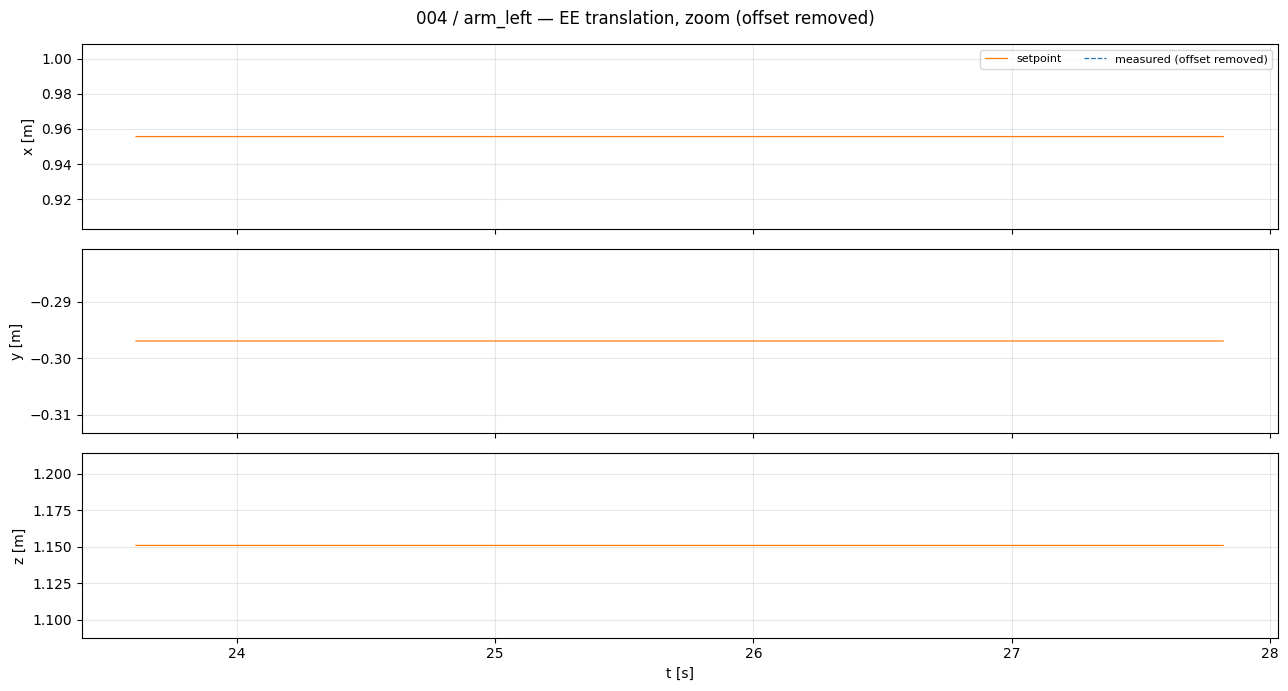

In [27]:
print(len(A["t"]))
start, stop = 11000, 13000
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(13, 7))
for i, lbl in enumerate("xyz"):
    sl = slice(start, stop)
    axs[i].plot(A["t"][sl], A["set_pos"][sl, i], lw=0.9, color="tab:orange", label="setpoint")
    axs[i].plot(A["t"][sl], A["pos"][sl, i] + LAG["offset_m"][i], lw=0.9, ls="--",
                color="tab:blue", label="measured (offset removed)")
    axs[i].set_ylabel(f"{lbl} [m]")
grid(axs, ncol=2)
plt.suptitle(f"{SESSION} / {ARM} — EE translation, zoom (offset removed)")
plt.tight_layout()


## How much lag, and is it really lag

Two independent estimates per axis. They use different properties of the signal, so
agreeing is evidence and disagreeing is a finding.

- **Left column** — error against commanded velocity. The fitted *slope* is the lag
  (error that grows with speed); the *intercept* is a constant offset (error that does
  not). This is the plot that separates the two.
- **Right column** — normalised cross-correlation against lag. The peak is the lag by
  waveform alignment. Positive means the arm lags; a peak left of zero would mean it
  leads, which would indicate a bug in the comparison rather than in the robot.


ValueError: zero-size array to reduction operation minimum which has no identity

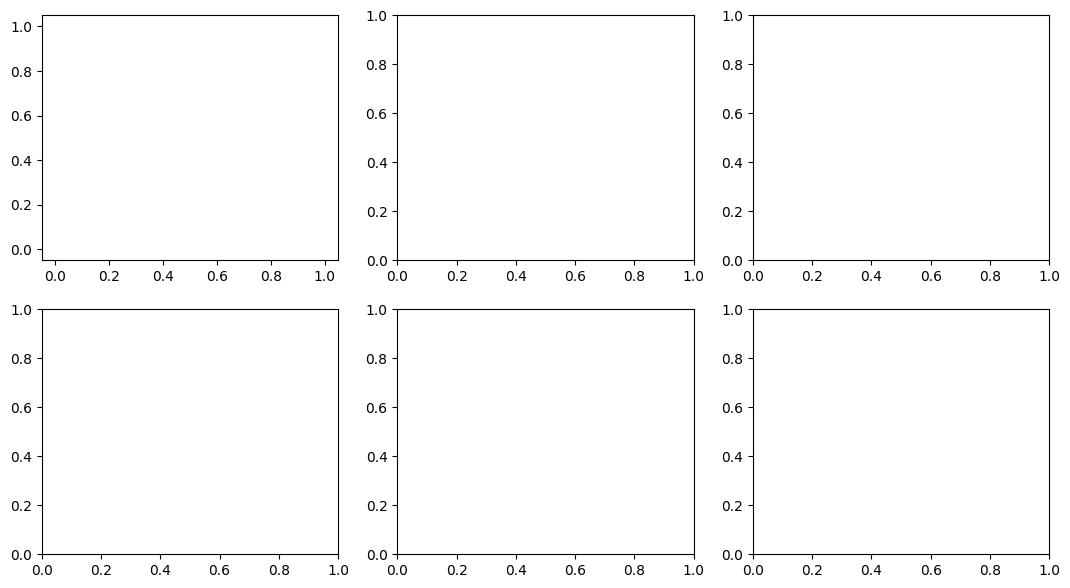

In [28]:
v_cmd = _smooth(np.gradient(A["set_pos"], A["t"], axis=0))
err_mm = _smooth(A["set_pos"] - A["pos"]) * 1e3
lags, R = LAG["_lags"], LAG["_R"]

fig, axs = plt.subplots(2, 3, figsize=(13, 7))
for i, lbl in enumerate("xyz"):
    peak, slope, b_mm = LAG["lag_ms"][i], LAG["slope_lag_ms"][i], LAG["offset_m"][i] * 1e3

    ax = axs[0, i]
    m = np.abs(v_cmd[:, i]) > 0.02
    ax.hexbin(v_cmd[m, i], err_mm[m, i], gridsize=45, cmap="Blues", mincnt=1, linewidths=0)
    xs = np.linspace(v_cmd[m, i].min(), v_cmd[m, i].max(), 2)
    ax.plot(xs, slope * xs + b_mm, color="tab:orange", lw=2,
            label=f"fit slope {slope:.0f} ms (low, see below)")
    ax.axhline(b_mm, color="0.35", lw=1.2, ls=":", label=f"offset {b_mm:+.1f} mm")
    ax.set_xlabel(f"commanded velocity {lbl} [m/s]")
    ax.set_ylabel("error (cmd − meas) [mm]" if i == 0 else "")
    ax.set_title(f"{lbl}:  error grows with speed  (R² {LAG['r2'][i]:.2f})", fontsize=9)
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3)

    ax = axs[1, i]
    ax.plot(lags, R[:, i], lw=1.4, color="tab:blue")
    ax.axvline(peak, color="tab:blue", lw=1.2, ls="--", label=f"lag {peak:.0f} ms")
    ax.axvline(slope, color="tab:orange", lw=1, ls=":", label=f"slope fit {slope:.0f} ms")
    ax.axvline(0, color="0.55", lw=0.9)
    ax.set_xlabel("lag [ms]   (>0 = arm lags)")
    ax.set_ylabel("normalised r" if i == 0 else "")
    ax.legend(fontsize=7, loc="lower center")
    ax.grid(True, alpha=0.3)

plt.suptitle(f"{SESSION} / {ARM} — tracking lag vs constant offset "
             f"(lag from cross-correlation, offset from the fit)")
plt.tight_layout()


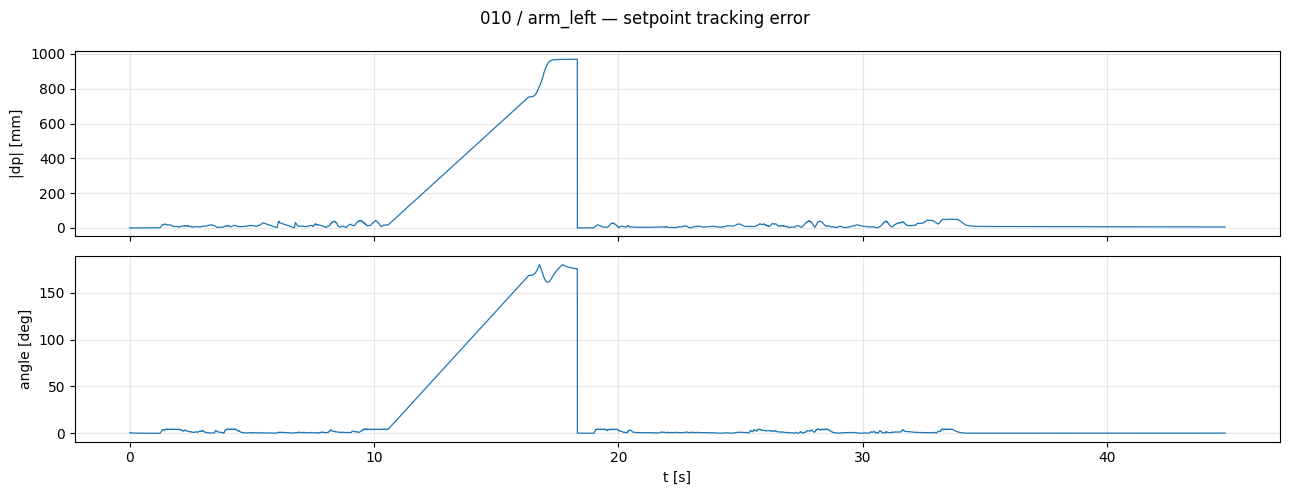

In [ ]:
# How far the arm is from the target it is currently being driven toward.
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(13, 5))
axs[0].plot(A["t"], np.linalg.norm(A["set_pos"] - A["pos"], axis=1) * 1e3, lw=0.9)
axs[0].set_ylabel("|dp| [mm]")
axs[1].plot(A["t"], np.degrees((A["set_rot"] * A["rot"].inv()).magnitude()), lw=0.9)
axs[1].set_ylabel("angle [deg]")
grid(axs)
plt.suptitle(f"{SESSION} / {ARM} — setpoint tracking error")
plt.tight_layout()

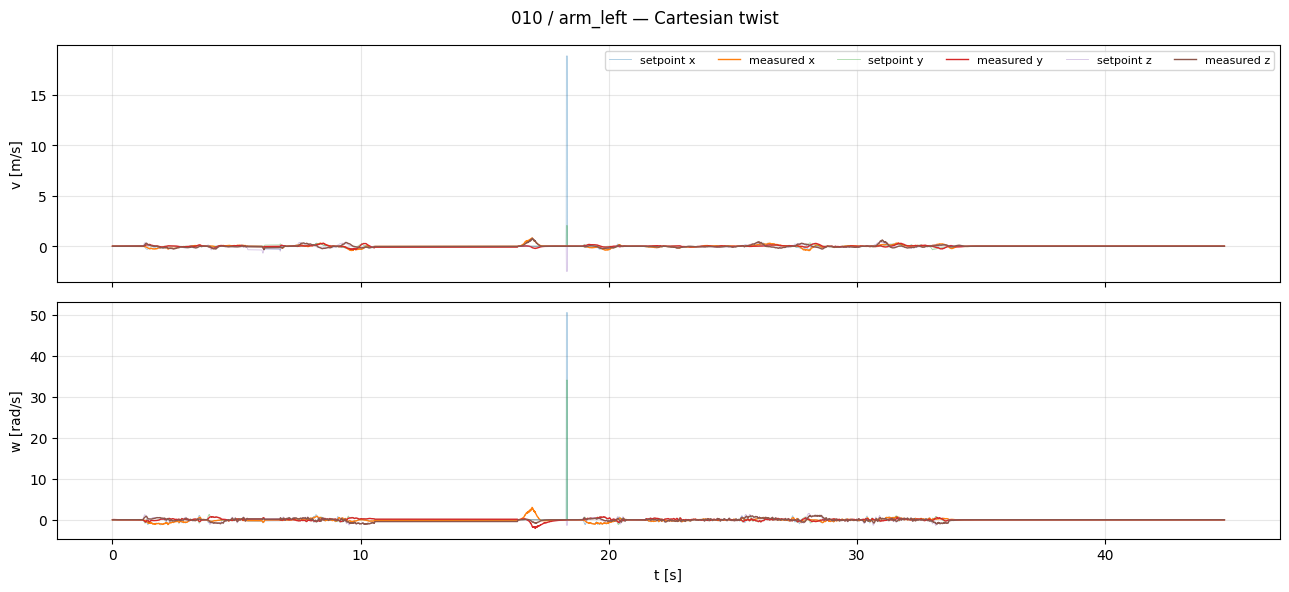

In [ ]:
# Twist, differentiated from the logged poses rather than J*dq. A sawtooth on the
# setpoint traces is the command rate showing through the motion generator, not noise.
v_m, v_s = deriv(A["t"], A["pos"]), deriv(A["t"], A["set_pos"])
w_m, w_s = ang_vel(A["t"], A["rot"]), ang_vel(A["t"], A["set_rot"])

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(13, 6))
for i, lbl in enumerate("xyz"):
    axs[0].plot(A["t"], v_s[:, i], lw=0.6, alpha=0.4, label=f"setpoint {lbl}")
    axs[0].plot(A["t"], v_m[:, i], lw=1.0, label=f"measured {lbl}")
    axs[1].plot(A["t"], w_s[:, i], lw=0.6, alpha=0.4, label=f"setpoint {lbl}")
    axs[1].plot(A["t"], w_m[:, i], lw=1.0, label=f"measured {lbl}")
axs[0].set_ylabel("v [m/s]")
axs[1].set_ylabel("w [rad/s]")
grid(axs, ncol=6)
plt.suptitle(f"{SESSION} / {ARM} — Cartesian twist")
plt.tight_layout()

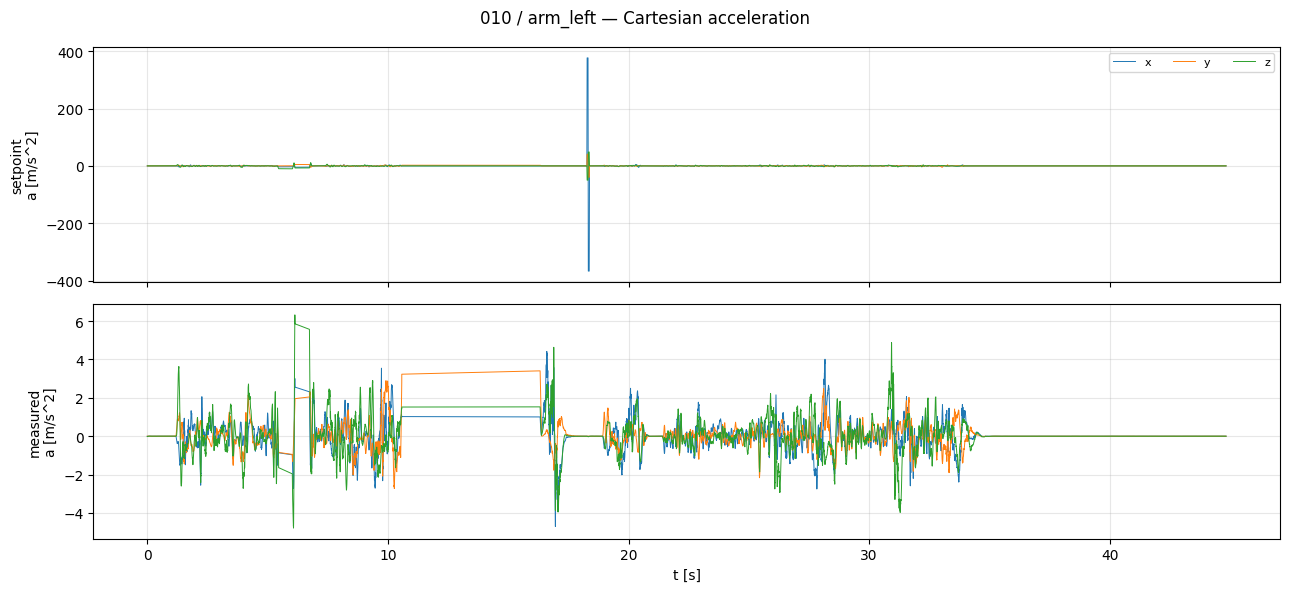

In [ ]:
# Acceleration is double-differentiated: read it for shape and timing, not magnitude.
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(13, 6))
for i, lbl in enumerate("xyz"):
    axs[0].plot(A["t"], deriv(A["t"], v_s)[:, i], lw=0.7, label=lbl)
    axs[1].plot(A["t"], deriv(A["t"], v_m)[:, i], lw=0.7, label=lbl)
axs[0].set_ylabel("setpoint\na [m/s^2]")
axs[1].set_ylabel("measured\na [m/s^2]")
grid(axs, ncol=3)
plt.suptitle(f"{SESSION} / {ARM} — Cartesian acceleration")
plt.tight_layout()

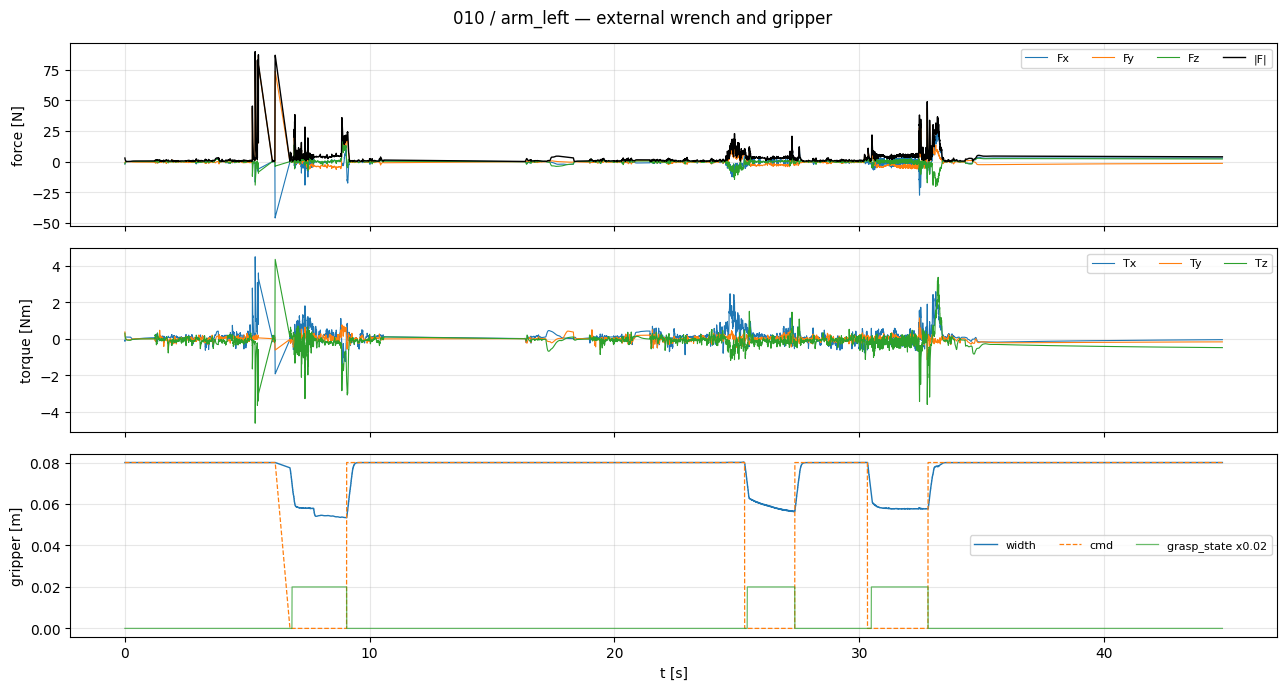

In [ ]:
# Contact. grasp_state is arm_control's sensor-derived confirmation
# (0 open / 1 held / 2 lost), not a repeat of the gripper command.
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(13, 7))
for i, lbl in enumerate("xyz"):
    axs[0].plot(A["t"], A["F_ext"][:, i], lw=0.8, label=f"F{lbl}")
    axs[1].plot(A["t"], A["F_ext"][:, 3 + i], lw=0.8, label=f"T{lbl}")
axs[0].plot(A["t"], np.linalg.norm(A["F_ext"][:, :3], axis=1), lw=1.0, color="k", label="|F|")
axs[0].set_ylabel("force [N]")
axs[1].set_ylabel("torque [Nm]")
axs[2].plot(A["t"], A["gripper_width"], lw=1.0, label="width")
axs[2].plot(A["t"], A["gripper_cmd"], lw=0.9, ls="--", label="cmd")
axs[2].plot(A["t"], A["grasp_state"] * 0.02, lw=0.9, alpha=0.7, label="grasp_state x0.02")
axs[2].set_ylabel("gripper [m]")
for ax in axs:
    ax.legend(ncol=4, fontsize=8)
grid(axs)
plt.suptitle(f"{SESSION} / {ARM} — external wrench and gripper")
plt.tight_layout()

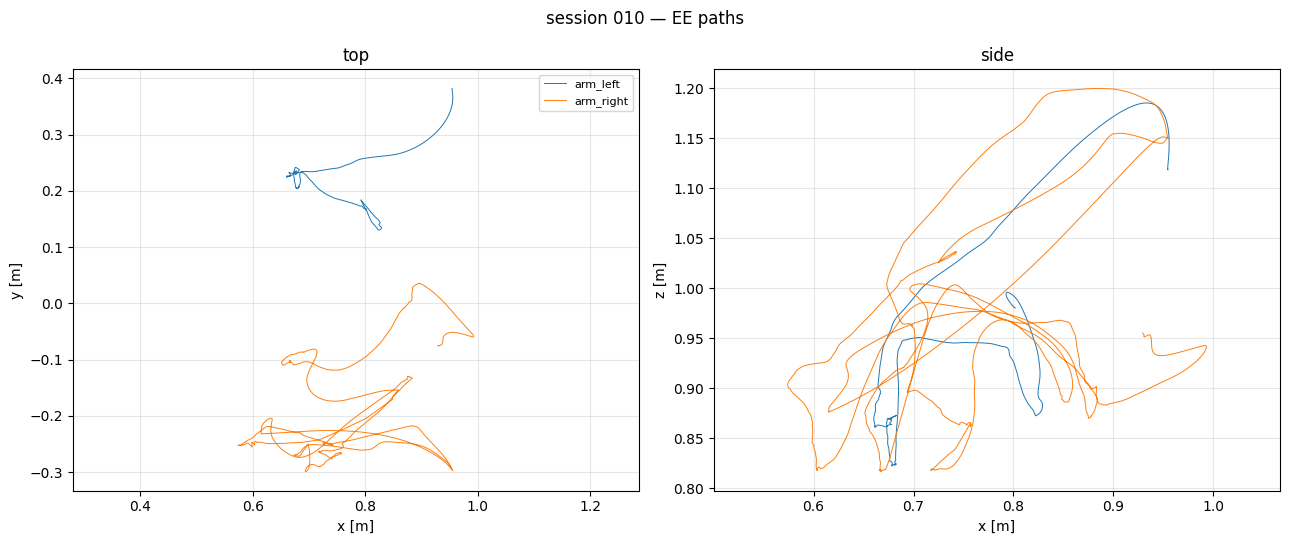

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
for name, d in arms.items():
    axs[0].plot(d["pos"][:, 0], d["pos"][:, 1], lw=0.7, label=name)
    axs[1].plot(d["pos"][:, 0], d["pos"][:, 2], lw=0.7, label=name)
axs[0].set_xlabel("x [m]"); axs[0].set_ylabel("y [m]"); axs[0].set_title("top")
axs[1].set_xlabel("x [m]"); axs[1].set_ylabel("z [m]"); axs[1].set_title("side")
for ax in axs:
    ax.set_aspect("equal", "datalim")
    ax.grid(True, alpha=0.3)
axs[0].legend(fontsize=8)
plt.suptitle(f"session {SESSION} — EE paths")
plt.tight_layout()

## Joints

Secondary: for explaining a Cartesian behaviour that already looks wrong. `tau_cmd` is
post rate-limit and post-saturation — exactly the vector handed to the robot — so a
flat top on it is the limiter, not the controller giving up.

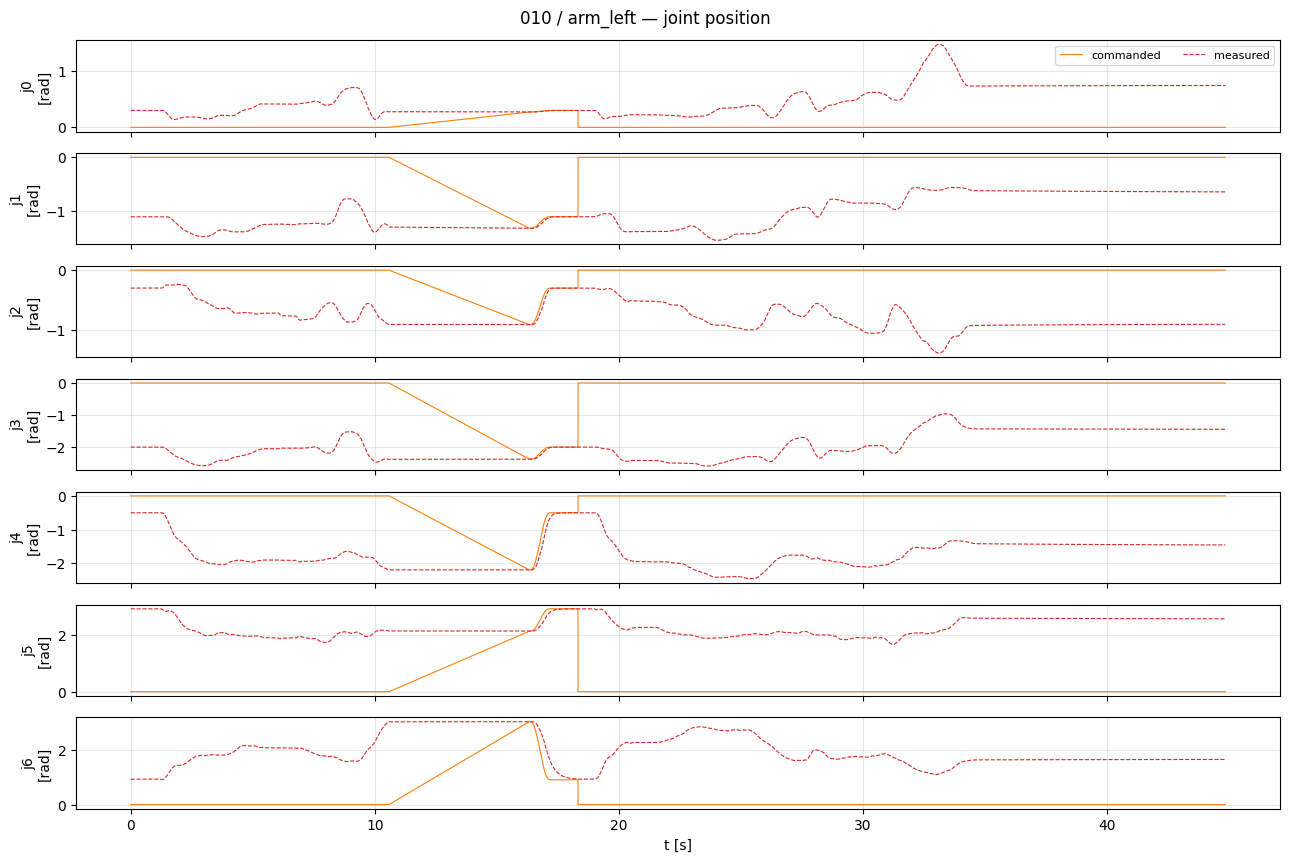

In [ ]:
def plot_joints(key, cmd_key=None, unit="", title=""):
    n = A[key].shape[1]
    fig, axs = plt.subplots(n, 1, sharex=True, figsize=(13, 1.25 * n))
    for j in range(n):
        if cmd_key:
            axs[j].plot(A["t"], A[cmd_key][:, j], lw=0.8, color="tab:orange", label="commanded")
        axs[j].plot(A["t"], A[key][:, j], lw=0.8, ls="--", color="tab:red", label="measured")
        axs[j].set_ylabel(f"j{j}\n{unit}")
    grid(axs, ncol=2)
    plt.suptitle(f"{SESSION} / {ARM} — {title or key}")
    plt.tight_layout()


plot_joints("q", "q_cmd", "[rad]", "joint position")

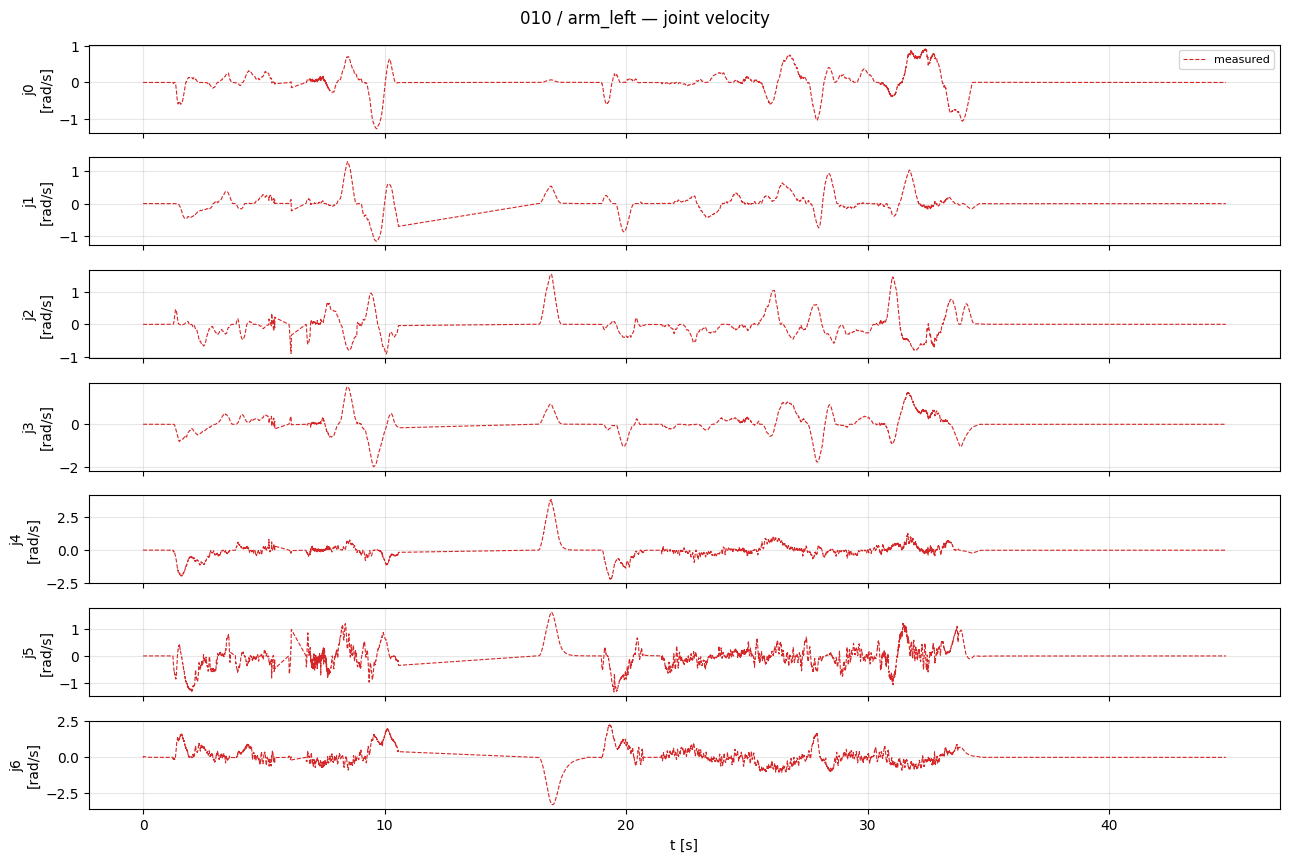

In [ ]:
plot_joints("dq", unit="[rad/s]", title="joint velocity")

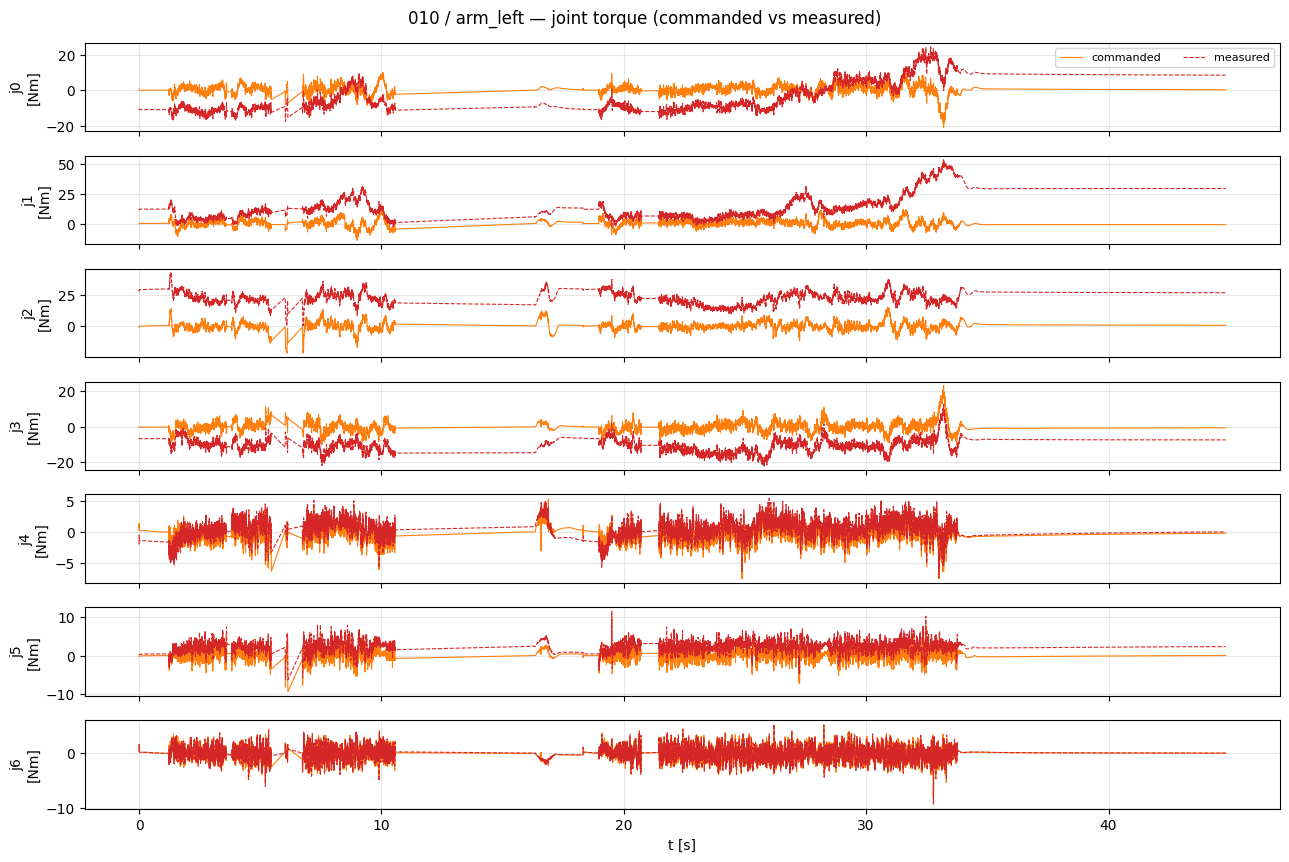

In [ ]:
plot_joints("tau_J", "tau_cmd", "[Nm]", "joint torque (commanded vs measured)")

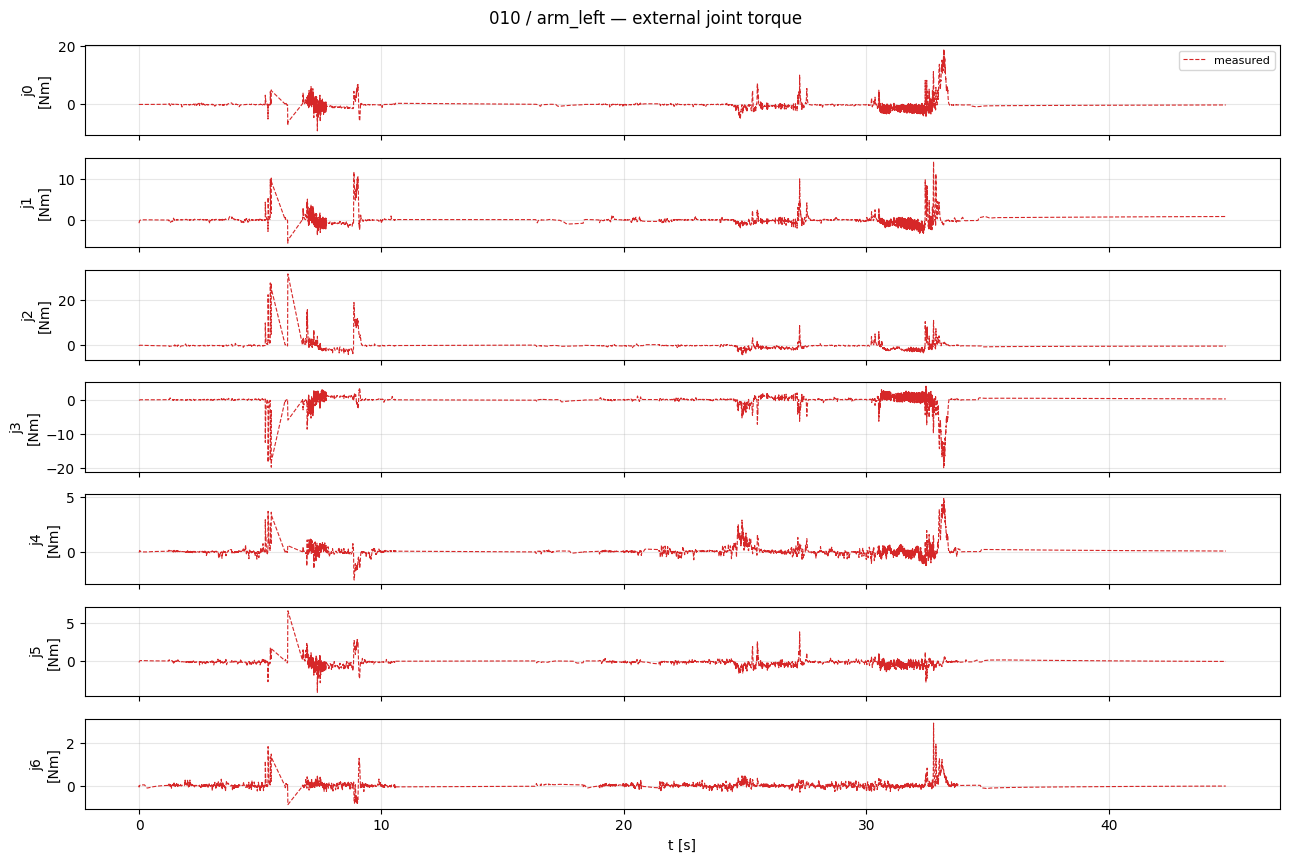

In [ ]:
plot_joints("tau_ext", unit="[Nm]", title="external joint torque")

## GMO vs MuJoCo ground truth

`<arm>_wrench_truth.csv` is MuJoCo's exact contact wrench, written beside the arm
log and joined on `sim_time`. The observer is a first-order filter with
`K_GMO = 50 rad/s` (~20 ms, ~8 Hz), so the raw truth leads it — the dashed trace
is the truth put through that same lag, and that is the fair comparison.

Read the residual panel first: `tau_contact + tau_friction + tau_limit` must equal
`tau_constraint`. If that is not flat, a sign or a constraint type is being
mishandled and nothing else here means anything.

arm_left: 5.5% of samples in contact
  free space  GMO |F|: p50  0.46  p95  2.06  p99.9 14.02  max 111.52 N   <- the estimator's noise floor
  in contact  GMO |F|: p50  4.88  p95  7.35  max  85.07 N
              MuJoCo : p50  8.71  p95 24.73  max  53.50 N
  corr(|F| GMO, |F| MuJoCo lag-matched) = 0.519


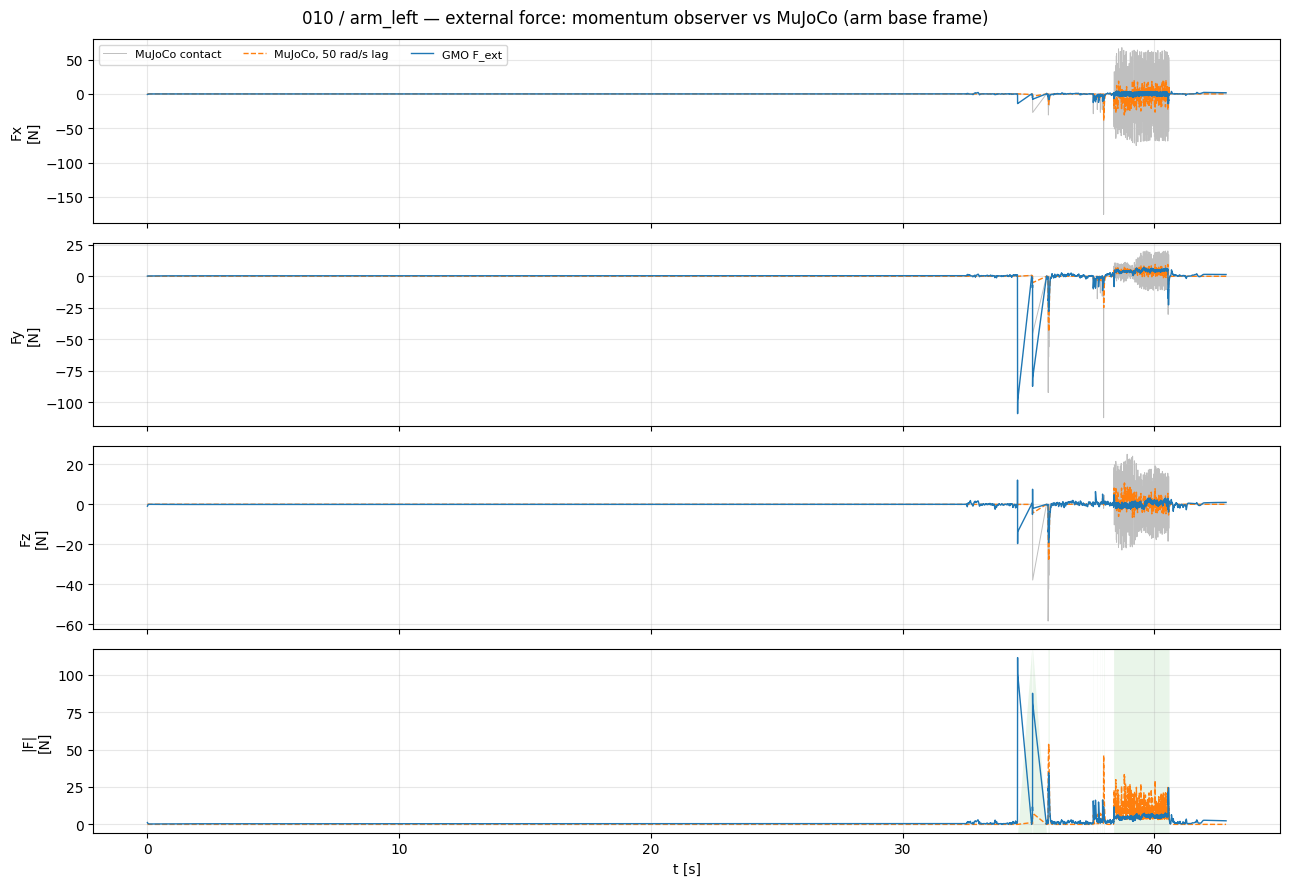

In [ ]:
K_GMO = 50.0   # must match K_GMO in sim_env/robot.hpp


def _lag(x, t, k=K_GMO):
    """The observer's own first-order lag, applied to the truth."""
    y = np.empty_like(x)
    y[0] = x[0]
    a = 1.0 - np.exp(-k * np.clip(np.diff(t), 1e-6, 1.0))
    for i in range(1, len(t)):
        y[i] = y[i - 1] + a[i - 1] * (x[i] - y[i - 1])
    return y


def load_truth(folder, arm):
    """Arm log and MuJoCo truth on a common sim_time axis.

    Deliberately re-reads the arm CSV rather than using load_arm(): the join key
    is sim_time, and load_arm keys everything on wall_clock_ns.
    """
    p = folder / f"{arm}_wrench_truth.csv"
    if not p.exists():
        print(f"{arm}: no {p.name} -- enable simulation.ground_truth_wrench in sim_config")
        return None

    cols = (["sim_time", "state"] + [f"tau_ext_{i}" for i in range(7)]
            + [f"F_ext_{i}" for i in range(6)])
    a = pd.read_csv(folder / f"{arm}.csv", sep=";", usecols=cols,
                    on_bad_lines="skip").dropna()
    a = a[a["sim_time"] > 0].sort_values("sim_time")
    if WINDOW == "engaged":
        idx = np.flatnonzero(a["state"].to_numpy() == ENGAGED)
        if len(idx) > 1:
            a = a.iloc[idx[0]:idx[-1] + 1]

    b = pd.read_csv(p, sep=";", on_bad_lines="skip").dropna(
        subset=["sim_time"]).sort_values("sim_time")

    t = a["sim_time"].to_numpy(float)
    # Window the truth to the arm's span too. Without this the residual panel
    # plots the whole session against a shared x-axis that the other panels only
    # cover the engaged part of, and the axis runs off to both sides.
    b = b[(b["sim_time"] >= t[0]) & (b["sim_time"] <= t[-1])]
    tb = b["sim_time"].to_numpy(float)
    grab = lambda df, c: df[c].to_numpy(float)
    on = lambda c: np.interp(t, tb, grab(b, c))

    d = {"t": t - t[0],
         "gmo_tau": np.column_stack([grab(a, f"tau_ext_{j}") for j in range(7)]),
         "gmo_F":   np.column_stack([grab(a, f"F_ext_{i}") for i in range(3)]),
         "mj_tau":  np.column_stack([on(f"tau_contact_{j}") for j in range(7)]),
         "mj_F":    np.column_stack([on(f"F_base_f{x}") for x in "xyz"]),
         "ncon":    on("ncon_arm"),
         # residual is a property of the truth file alone, so keep its own axis
         "tb":      tb - t[0],
         "resid":   np.column_stack([
                        grab(b, f"tau_constraint_{j}")
                        - grab(b, f"tau_contact_{j}")
                        - grab(b, f"tau_friction_{j}")
                        - grab(b, f"tau_limit_{j}") for j in range(7)]),
         "mj_fric": np.column_stack([grab(b, f"tau_friction_{j}") for j in range(7)]),
         "mj_lim":  np.column_stack([grab(b, f"tau_limit_{j}") for j in range(7)])}
    for k in ("mj_tau", "mj_F"):
        d[k + "_lag"] = np.column_stack(
            [_lag(d[k][:, i], d["t"]) for i in range(d[k].shape[1])])
    return d


T = load_truth(folder, ARM)

if T is not None:
    fig, axs = plt.subplots(4, 1, sharex=True, figsize=(13, 9))
    for i, lbl in enumerate("xyz"):
        axs[i].plot(T["t"], T["mj_F"][:, i], lw=0.7, color="0.75", label="MuJoCo contact")
        axs[i].plot(T["t"], T["mj_F_lag"][:, i], lw=1.0, ls="--", color="tab:orange",
                    label=f"MuJoCo, {K_GMO:.0f} rad/s lag")
        axs[i].plot(T["t"], T["gmo_F"][:, i], lw=1.0, color="tab:blue", label="GMO F_ext")
        axs[i].set_ylabel(f"F{lbl}\n[N]")

    axs[3].plot(T["t"], np.linalg.norm(T["mj_F_lag"], axis=1), lw=1.0, ls="--",
                color="tab:orange", label="|F| MuJoCo, lag-matched")
    axs[3].plot(T["t"], np.linalg.norm(T["gmo_F"], axis=1), lw=1.0, color="tab:blue",
                label="|F| GMO")
    axs[3].fill_between(T["t"], 0, T["ncon"] > 0.5, transform=axs[3].get_xaxis_transform(),
                        color="tab:green", alpha=0.10, lw=0, label="in contact")
    axs[3].set_ylabel("|F|\n[N]")

    grid(axs, ncol=3)
    plt.suptitle(f"{SESSION} / {ARM} — external force: momentum observer vs MuJoCo "
                 f"(arm base frame)")
    plt.tight_layout()

    inc = T["ncon"] > 0.5
    mg = np.linalg.norm(T["gmo_F"], axis=1)
    mt = np.linalg.norm(T["mj_F_lag"], axis=1)
    print(f"{ARM}: {inc.mean() * 100:.1f}% of samples in contact")
    print(f"  free space  GMO |F|: p50 {np.median(mg[~inc]):5.2f}  "
          f"p95 {np.percentile(mg[~inc], 95):5.2f}  p99.9 {np.percentile(mg[~inc], 99.9):5.2f}  "
          f"max {mg[~inc].max():6.2f} N   <- the estimator's noise floor")
    if inc.any():
        print(f"  in contact  GMO |F|: p50 {np.median(mg[inc]):5.2f}  "
              f"p95 {np.percentile(mg[inc], 95):5.2f}  max {mg[inc].max():6.2f} N")
        print(f"              MuJoCo : p50 {np.median(mt[inc]):5.2f}  "
              f"p95 {np.percentile(mt[inc], 95):5.2f}  max {mt[inc].max():6.2f} N")
    print(f"  corr(|F| GMO, |F| MuJoCo lag-matched) = {np.corrcoef(mg, mt)[0, 1]:.3f}")

decomposition residual: max 1.00e-06 Nm   OK (at CSV print precision)

joint   rms err   rms lag-matched  truth rms    corr
    0     4.073             1.307      4.103   0.242
    1     3.830             1.205      3.824   0.085
    2     3.446             1.162      3.459   0.277
    3     3.349             1.088      3.386   0.379
    4     0.224             0.154      0.188   0.423
    5     1.649             0.527      1.664   0.289
    6     0.106             0.087      0.069   0.239


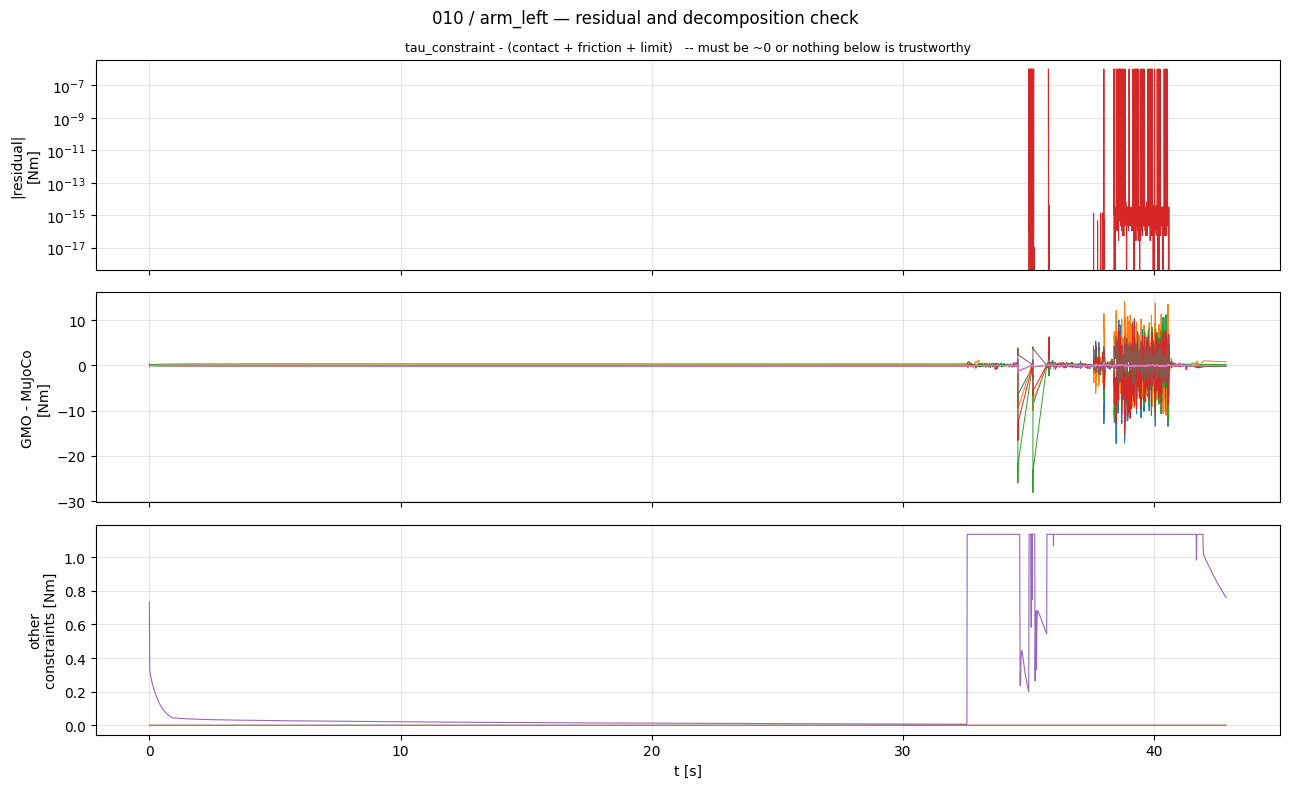

In [ ]:
if T is not None:
    fig, axs = plt.subplots(3, 1, sharex=True, figsize=(13, 8))

    # 1. the self-check: does the decomposition close?
    r = np.abs(T["resid"]).max(axis=1)
    axs[0].plot(T["tb"], r, lw=0.8, color="tab:red")
    axs[0].set_ylabel("|residual|\n[Nm]")
    axs[0].set_title("tau_constraint - (contact + friction + limit)   "
                     "-- must be ~0 or nothing below is trustworthy", fontsize=9)
    axs[0].set_yscale("log")

    # 2. per-joint observer error against the lag-matched truth
    err = T["gmo_tau"] - T["mj_tau_lag"]
    for j in range(7):
        axs[1].plot(T["t"], err[:, j], lw=0.7, label=f"j{j}")
    axs[1].set_ylabel("GMO - MuJoCo\n[Nm]")

    # 3. what the observer cannot see: MuJoCo solves dry friction as a constraint,
    #    and the observer models it internally instead. If the friction model were
    #    wrong, that error would show up in panel 2 with this shape.
    axs[2].plot(T["tb"], np.abs(T["mj_fric"]).max(axis=1), lw=0.8, color="tab:purple",
                label="max |friction|")
    axs[2].plot(T["tb"], np.abs(T["mj_lim"]).max(axis=1), lw=0.8, color="tab:brown",
                label="max |joint limit|")
    axs[2].set_ylabel("other\nconstraints [Nm]")

    grid(axs, ncol=7)
    plt.suptitle(f"{SESSION} / {ARM} — residual and decomposition check")
    plt.tight_layout()

    # 1e-6 is the CSV's own print precision (%.6f), not estimator error: the
    # decomposition is exact to the limit of what was written to disk.
    rmax = np.abs(T["resid"]).max()
    print(f"decomposition residual: max {rmax:.2e} Nm   "
          f"{'OK (at CSV print precision)' if rmax < 1e-5 else 'NOT FLAT -- fix this first'}")
    print(f"\n{'joint':>5} {'rms err':>9} {'rms lag-matched':>17} {'truth rms':>10} {'corr':>7}")
    for j in range(7):
        raw = np.sqrt(np.mean((T["gmo_tau"][:, j] - T["mj_tau"][:, j]) ** 2))
        lagm = np.sqrt(np.mean(err[:, j] ** 2))
        tr = np.sqrt(np.mean(T["mj_tau"][:, j] ** 2))
        cc = np.corrcoef(T["gmo_tau"][:, j], T["mj_tau_lag"][:, j])[0, 1]
        print(f"{j:>5} {raw:>9.3f} {lagm:>17.3f} {tr:>10.3f} {cc:>7.3f}")

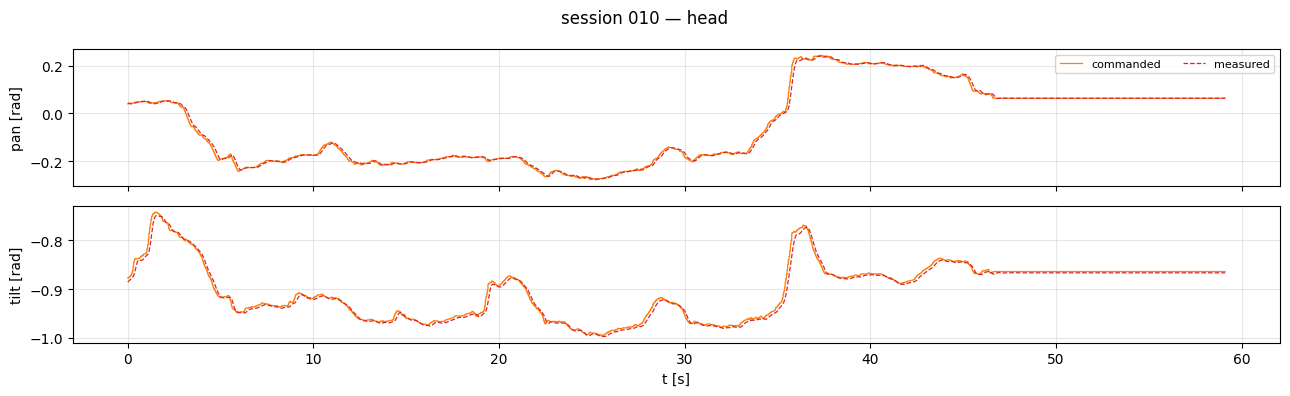

In [ ]:
if head is not None:
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(13, 4))
    for j, lbl in enumerate(("pan", "tilt")):
        axs[j].plot(head["t"], head["q_cmd"][:, j], lw=0.9, color="tab:orange", label="commanded")
        axs[j].plot(head["t"], head["q"][:, j], lw=0.9, ls="--", color="tab:red", label="measured")
        axs[j].set_ylabel(f"{lbl} [rad]")
    grid(axs, ncol=2)
    plt.suptitle(f"session {SESSION} — head")
    plt.tight_layout()
else:
    print("no head.csv in this session")